In [ ]:
!pip install pandas numpy matplotlib seaborn statsmodels fredapi scikit-learn


In [ ]:
from fredapi import Fred
import pandas as pd
import matplotlib.pyplot as plt

# 1. Wake up the FRED connection using your unique API key
# MAKE SURE TO REPLACE THIS STRING WITH YOUR ACTUAL KEY
fred = Fred(api_key='f51b318113ad32c8799263c3914e0ade')

# 2. Download our 4 core variables (10 years of daily data from June 2016 to June 2026)
print("Fetching raw data from FRED servers... Please wait...")

# Y Variable: ICE BofA US High Yield Index Option-Adjusted Spread
high_yield_spread = fred.get_series('BAMLH0A0HYM2', start_date='2016-06-01', end_date='2026-06-01')

# X1 Variable: VIX (Market Volatility / Fear Index)
vix = fred.get_series('VIXCLS', start_date='2016-06-01', end_date='2026-06-01')

# X2 Variable: Effective Federal Funds Rate (Macro Monetary Policy)
fed_funds = fred.get_series('FEDFUNDS', start_date='2016-06-01', end_date='2026-06-01')

# 3. Combine everything into a single table (Pandas DataFrame)
df = pd.DataFrame({
    'Spread': high_yield_spread,
    'VIX': vix,
    'Fed_Funds': fed_funds
})

# 4. Clean up the rows. FRED fills weekends with missing values (NaN).
# We remove any row where 'Spread' or 'VIX' is missing.
df = df.dropna(subset=['Spread', 'VIX'])

# 5. Since 'Fed_Funds' is a monthly rate, it only updates once a month.
# We use forward-fill (.ffill()) to tell Python: "If today's Fed Funds rate is blank,
# use the value from yesterday until the new month updates."
df['Fed_Funds'] = df['Fed_Funds'].ffill()

# 6. Drop any leftover rows that still have empty slots
df = df.dropna()

print("\n--- Kitchen Setup Complete! Here are the first 5 rows of your master dataset: ---")
print(df.head())
print(f"\nTotal data points collected: {len(df)} days.")


Fetching raw data from FRED servers... Please wait...

--- Kitchen Setup Complete! Here are the first 5 rows of your master dataset: ---
            Spread    VIX  Fed_Funds
2023-08-01    3.82  13.93       5.33
2023-08-02    3.96  16.09       5.33
2023-08-03    3.98  15.92       5.33
2023-08-04    4.01  17.10       5.33
2023-08-07    3.97  15.77       5.33

Total data points collected: 736 days.


In [ ]:
from statsmodels.tsa.stattools import adfuller

# 1. Create a function to run the test and translate the output into plain English
def check_stationarity(series_data, column_name):
    print(f"=== Running Augmented Dickey-Fuller Test for: {column_name} ===")

    # Run the math model
    result = adfuller(series_data)

    test_statistic = result[0]
    p_value = result[1]

    print(f"ADF Test Statistic: {test_statistic:.4f}")
    print(f"p-value: {p_value:.4f}")

    # Check the 5% significance threshold
    if p_value < 0.05:
        print(f"Conclusion: p-value is less than 0.05. Reject H0. The series is STATIONARY. \n")
    else:
        print(f"Conclusion: p-value is greater than 0.05. Fail to reject H0. The series is NON-STATIONARY. \n")

# 2. Run our master variables through the test function
check_stationarity(df['Spread'], 'Spread (Y)')
check_stationarity(df['VIX'], 'VIX (X1)')
check_stationarity(df['Fed_Funds'], 'Fed_Funds (X2)')

=== Running Augmented Dickey-Fuller Test for: Spread (Y) ===
ADF Test Statistic: -2.7124
p-value: 0.0719
Conclusion: p-value is greater than 0.05. Fail to reject H0. The series is NON-STATIONARY. 

=== Running Augmented Dickey-Fuller Test for: VIX (X1) ===
ADF Test Statistic: -4.9896
p-value: 0.0000
Conclusion: p-value is less than 0.05. Reject H0. The series is STATIONARY. 

=== Running Augmented Dickey-Fuller Test for: Fed_Funds (X2) ===
ADF Test Statistic: 0.0922
p-value: 0.9655
Conclusion: p-value is greater than 0.05. Fail to reject H0. The series is NON-STATIONARY. 



In [ ]:
# 1. Create a brand new copy of our dataframe to hold the transformed data
df_diff = pd.DataFrame()

# 2. VIX was already stationary, so we keep it exactly as it was
df_diff['VIX'] = df['VIX']

# 3. Calculate the daily change (First Difference) for our non-stationary variables using .diff()
df_diff['Spread_Diff'] = df['Spread'].diff()
df_diff['Fed_Funds_Diff'] = df['Fed_Funds'].diff()

# 4. Because calculating a difference requires yesterday's data,
# the very first row in our dataset (Row 0) won't have a "yesterday".
# Python marks it as NaN. We drop that single empty row.
df_diff = df_diff.dropna()

print("--- Data Transformation Complete! ---")
print("Here are the first 5 rows of your daily differences dataset:")
print(df_diff.head())

print("\n")

# 5. Let's re-run our ADF test on the newly differenced variables to check our math
check_stationarity(df_diff['Spread_Diff'], 'Differenced Spread (ΔY)')
check_stationarity(df_diff['Fed_Funds_Diff'], 'Differenced Fed_Funds (ΔX2)')

--- Data Transformation Complete! ---
Here are the first 5 rows of your daily differences dataset:
              VIX  Spread_Diff  Fed_Funds_Diff
2023-08-02  16.09         0.14             0.0
2023-08-03  15.92         0.02             0.0
2023-08-04  17.10         0.03             0.0
2023-08-07  15.77        -0.04             0.0
2023-08-08  15.99         0.03             0.0


=== Running Augmented Dickey-Fuller Test for: Differenced Spread (ΔY) ===
ADF Test Statistic: -24.2404
p-value: 0.0000
Conclusion: p-value is less than 0.05. Reject H0. The series is STATIONARY. 

=== Running Augmented Dickey-Fuller Test for: Differenced Fed_Funds (ΔX2) ===
ADF Test Statistic: -27.2496
p-value: 0.0000
Conclusion: p-value is less than 0.05. Reject H0. The series is STATIONARY. 



In [ ]:
# 1. Create our prediction targets and lagged features
df_features = pd.DataFrame()

# Target Variable (Y): Today's change in the bond spread
df_features['Target_Spread_Change'] = df_diff['Spread_Diff']

# Feature 1 (X1): Yesterday's change in the bond spread (Self-memory / Autoregressive component)
df_features['Spread_Change_Yesterday'] = df_diff['Spread_Diff'].shift(1)

# Feature 2 (X2): Yesterday's actual VIX level
df_features['VIX_Yesterday'] = df_diff['VIX'].shift(1)

# Feature 3 (X3): Yesterday's change in the Fed Funds Rate
df_features['Fed_Funds_Change_Yesterday'] = df_diff['Fed_Funds_Diff'].shift(1)

# 2. Because shifting data down by 1 row creates a blank NaN in the very first row, we drop it
df_features = df_features.dropna()

print("--- Forecasting Features Created! ---")
print("Look at how the dates align yesterday's market conditions with today's target:")
print(df_features.head())

--- Forecasting Features Created! ---
Look at how the dates align yesterday's market conditions with today's target:
            Target_Spread_Change  Spread_Change_Yesterday  VIX_Yesterday  \
2023-08-03                  0.02                     0.14          16.09   
2023-08-04                  0.03                     0.02          15.92   
2023-08-07                 -0.04                     0.03          17.10   
2023-08-08                  0.03                    -0.04          15.77   
2023-08-09                 -0.06                     0.03          15.99   

            Fed_Funds_Change_Yesterday  
2023-08-03                         0.0  
2023-08-04                         0.0  
2023-08-07                         0.0  
2023-08-08                         0.0  
2023-08-09                         0.0  


In [ ]:
# 1. Define our Matrix of Independent Variables (X) and Vector of Dependent Target (y)
X = df_features[['Spread_Change_Yesterday', 'VIX_Yesterday', 'Fed_Funds_Change_Yesterday']]
y = df_features['Target_Spread_Change']

# 2. Calculate the cutoff index point for an 80/20 chronological split
split_point = int(len(df_features) * 0.80)

# 3. Slice the data chronologically (No Shuffling!)
X_train = X.iloc[:split_point]
X_test = X.iloc[split_point:]

y_train = y.iloc[:split_point]
y_test = y.iloc[split_point:]

print("--- Chronological Data Split Complete! ---")
print(f"Total rows in entire dataset: {len(df_features)}")
print(f"Training rows (Past 80%): {len(X_train)} rows (From {X_train.index[0].date()} to {X_train.index[-1].date()})")
print(f"Testing rows (Future 20%): {len(X_test)} rows (From {X_test.index[0].date()} to {X_test.index[-1].date()})")

--- Chronological Data Split Complete! ---
Total rows in entire dataset: 734
Training rows (Past 80%): 587 rows (From 2023-08-03 to 2025-11-10)
Testing rows (Future 20%): 147 rows (From 2025-11-11 to 2026-06-08)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# 1. Initialize the Random Forest Regressor engine
# n_estimators=100 means we are building a forest of 100 individual decision trees
# random_state=42 locks the random seed so your results are perfectly reproducible
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Train the model using our past historical training data (.fit())
# This is where the algorithm studies the patterns between yesterday's signals and today's changes
print("Training the Random Forest model... analyzing historical patterns...")
rf_model.fit(X_train, y_train)

# 3. Generate our out-of-sample forecasts on the testing data (.predict())
# The model only gets to look at X_test (yesterday's signals) to guess y_test (tomorrow's target)
print("Generating out-of-sample forecasts for the test period...")
predictions = rf_model.predict(X_test)

# 4. Put the actual results and our model's forecasts side-by-side to inspect them
results_df = pd.DataFrame({
    'Actual_Spread_Change': y_test,
    'Predicted_Spread_Change': predictions
}, index=y_test.index)

print("\n--- Model Training & Forecasting Complete! ---")
print("Here are the first 5 rows of actual market movements vs your model's predictions:")
print(results_df.head())

Training the Random Forest model... analyzing historical patterns...
Generating out-of-sample forecasts for the test period...

--- Model Training & Forecasting Complete! ---
Here are the first 5 rows of actual market movements vs your model's predictions:
            Actual_Spread_Change  Predicted_Spread_Change
2025-11-11                  0.00                  -0.0155
2025-11-12                  0.00                   0.0319
2025-11-13                  0.07                   0.0457
2025-11-14                 -0.02                   0.0614
2025-11-17                  0.06                  -0.0119


=== Model Performance Metrics ===
Mean Absolute Error (MAE): 0.0450 percentage points
Directional Accuracy: 42.86%



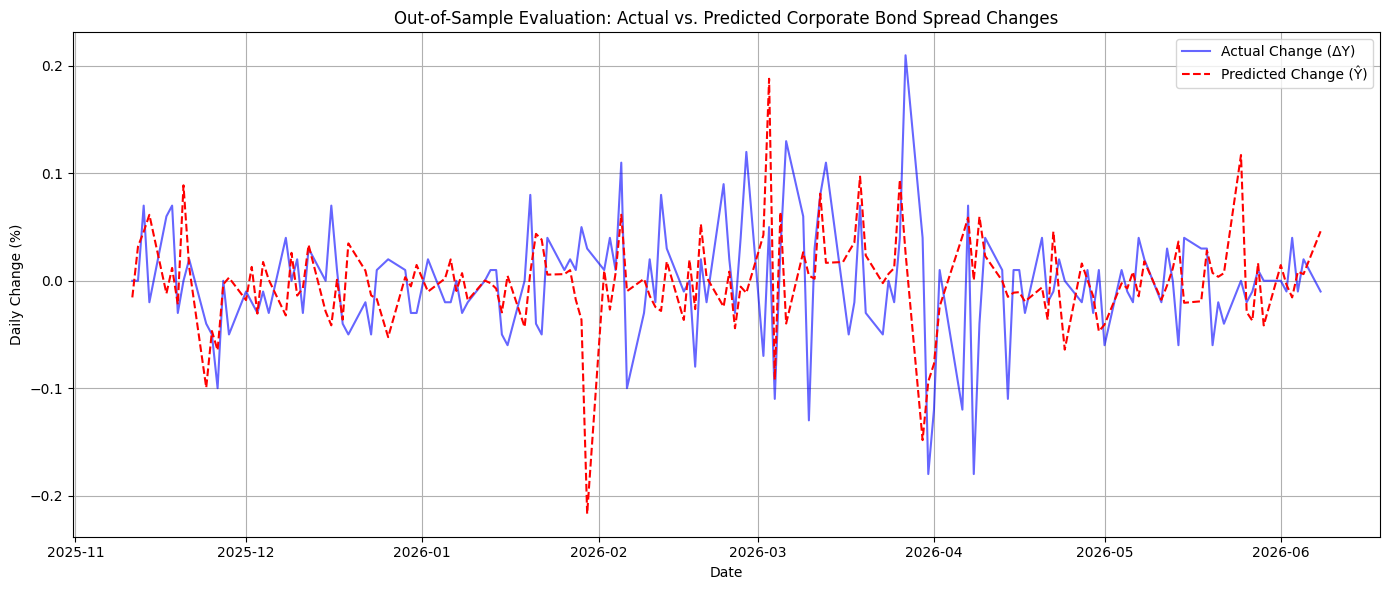

In [ ]:
from sklearn.metrics import mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# 1. Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(results_df['Actual_Spread_Change'], results_df['Predicted_Spread_Change'])

# 2. Calculate Directional Accuracy (Did the signs match?)
# np.sign() returns +1 for positive changes, -1 for negative changes, and 0 for no change
actual_signs = np.sign(results_df['Actual_Spread_Change'])
predicted_signs = np.sign(results_df['Predicted_Spread_Change'])

# Count how often the predicted sign matched the actual sign
correct_direction = (actual_signs == predicted_signs).sum()
directional_accuracy = (correct_direction / len(results_df)) * 100

print("=== Model Performance Metrics ===")
print(f"Mean Absolute Error (MAE): {mae:.4f} percentage points")
print(f"Directional Accuracy: {directional_accuracy:.2f}%\n")

# 3. Plot the Actual vs Predicted Changes for visual confirmation
plt.figure(figsize=(14, 6))
plt.plot(results_df.index, results_df['Actual_Spread_Change'], label='Actual Change (ΔY)', color='blue', alpha=0.6)
plt.plot(results_df.index, results_df['Predicted_Spread_Change'], label='Predicted Change (Ŷ)', color='red', linestyle='--')
plt.title('Out-of-Sample Evaluation: Actual vs. Predicted Corporate Bond Spread Changes')
plt.ylabel('Daily Change (%)')
plt.xlabel('Date')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

=== Macro Feature Importance Rankings ===
                      Feature  Importance_Score
1               VIX_Yesterday          0.643528
0     Spread_Change_Yesterday          0.353167
2  Fed_Funds_Change_Yesterday          0.003306


/tmp/ipykernel_1003/3513274495.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance_Score', y='Feature', data=importance_df, palette='viridis')


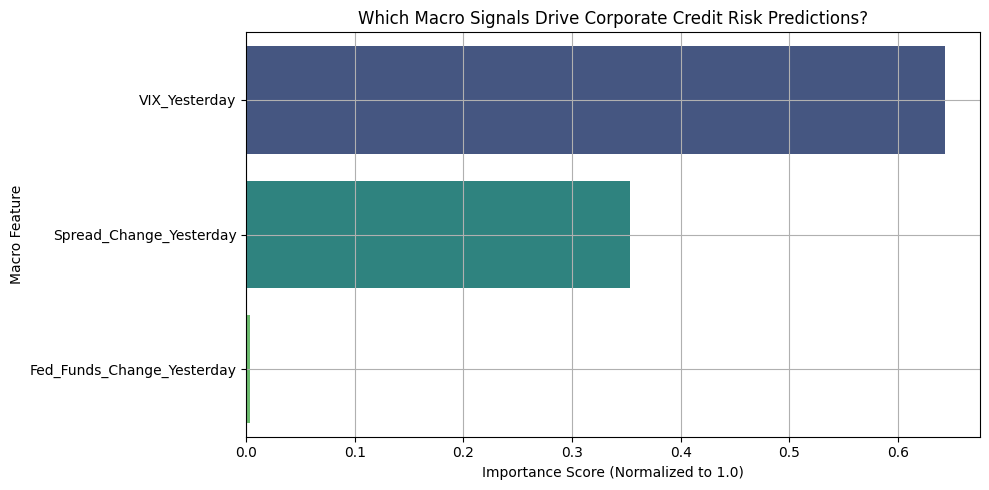

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract the mathematical importance scores from our trained forest
importances = rf_model.feature_importances_

# 2. Match the scores up with our feature names
feature_names = X.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Score': importances
}).sort_values(by='Importance_Score', ascending=False)

print("=== Macro Feature Importance Rankings ===")
print(importance_df)

# 3. Draw a bar chart to visualize the rankings
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance_Score', y='Feature', data=importance_df, palette='viridis')
plt.title('Which Macro Signals Drive Corporate Credit Risk Predictions?')
plt.xlabel('Importance Score (Normalized to 1.0)')
plt.ylabel('Macro Feature')
plt.grid(True)
plt.tight_layout()
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 98.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 12.6 MB/s eta 0:00:00
  Attempting uninstall: shap
    Found existing installation: shap 0.52.0
    Uninstalling shap-0.52.0:
      Successfully uninstalled shap-0.52.0
Step 1: Simulating Confounded Corporate Bond Market Data...

Step 2: Initializing Double Machine Learning (DML) via EconML...

=== Causal Identification Summary ===
                  Coefficient Results                   
   point_estimate stderr zstat  pvalue ci_lower ci_upper
--------------------------------------------------------
X0         -0.326  0.194 -1.678  0.093   -0.708    0.055
X1          0.874  0.044 19.697    0.0    0.787     0.96
                       CATE Intercept Results                       
               point_estimate stderr zstat  pvalue ci_lower ci_upper
------------------------------

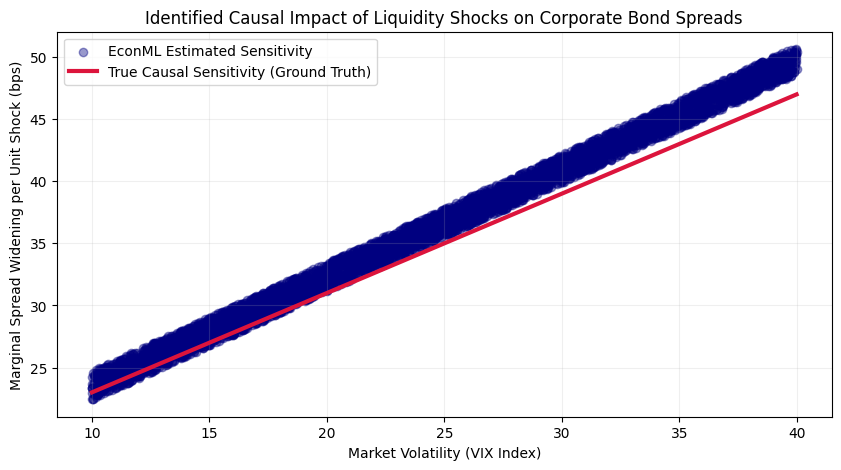


=== Causal Inference Upgrade Complete ===


In [3]:
!pip install econml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from econml.dml import LinearDML
from sklearn.ensemble import RandomForestRegressor

# ==========================================================
# STEP 1: SIMULATE OBSERVATIONAL BOND MARKET DATA WITH BIAS
# ==========================================================
print("Step 1: Simulating Confounded Corporate Bond Market Data...")
np.random.seed(42)
n_bonds = 5000

# Macro Confounders (X): GDP Growth Rate (%) and VIX Volatility Index
gdp_growth = np.random.uniform(-2, 5, n_bonds)
vix = np.random.uniform(10, 40, n_bonds)
X = np.column_stack((gdp_growth, vix))

# Treatment (T): High-Yield Liquidity Risk Metric (Shock intensity)
# Heavily confounded: Bad macro climates (low GDP, high VIX) naturally cause higher shocks
liquidity_propensity = 2.0 - 0.5 * gdp_growth + 0.1 * vix
T = liquidity_propensity + np.random.normal(0, 0.5, n_bonds)

# True Heterogeneous Causal Effect: Shocks widen spreads more when VIX is already high!
# True Effect = 15 + 0.8 * VIX
true_effect = 15 + 0.8 * vix

# Outcome (Y): Corporate Bond Spread (in basis points)
# Driven by macro fundamentals AND the structural liquidity shock
Y = 120 - 15 * gdp_growth + 4 * vix + true_effect * T + np.random.normal(0, 10, n_bonds)

# ==========================================================
# STEP 2: APPLY MICROSOFT ECONML (DOUBLE MACHINE LEARNING)
# ==========================================================
print("\nStep 2: Initializing Double Machine Learning (DML) via EconML...")

# We use flexible Random Forests to model and strip away the macro-economic backgrounds
dml_estimator = LinearDML(
    model_y=RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    model_t=RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    featurizer=None,
    random_state=42
)

# Fit the structural causal model
dml_estimator.fit(Y, T, X=X)

# Predict customer/bond-specific conditional marginal effects
predicted_marginal_effects = dml_estimator.effect(X)

print("\n=== Causal Identification Summary ===")
print(dml_estimator.summary())

# ==========================================================
# STEP 3: VISUALIZE IDENTIFIED CAUSAL MECHANISM VS. TRUTH
# ==========================================================
print("\nStep 3: Compiling Counterfactual Causal Diagnostics...")

plt.figure(figsize=(10, 5))
# Sort by VIX to see the trend clearly
sort_idx = np.argsort(vix)

plt.scatter(vix, predicted_marginal_effects, color='navy', alpha=0.4, label='EconML Estimated Sensitivity')
plt.plot(vix[sort_idx], true_effect[sort_idx], color='crimson', linewidth=3, label='True Causal Sensitivity (Ground Truth)')

plt.title('Identified Causal Impact of Liquidity Shocks on Corporate Bond Spreads', fontsize=12)
plt.xlabel('Market Volatility (VIX Index)')
plt.ylabel('Marginal Spread Widening per Unit Shock (bps)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print("\n=== Causal Inference Upgrade Complete ===")